# CIFAR-10 Dataset - Model Training

### Definisanje arhitekture i treniranje modela
- Arhitektura u zasebnom modulu (<b>model_arhitecture.py</b>)
- Cross-validacija
- Optimizacija hiperparametara
- Automatsko logovanje (MLflow)
- Fiksiran random seed
- Logovanje verzija biblioteka

In [2]:
import numpy as numpy
import pandas as pd 
import matplotlib.pyplot as plt 
import seaborn as sns
import tensorflow as tf 
from tensorflow import keras
import warnings
warnings.filterwarnings('ignore')

#Import modula
from model_arhitecture import CIFAR10CNN, create_data_augmentation
from train_model import CIFAR10Trainer

print(f"TensorFlow version: {tf.__version__}")
print(f"Keras version: {keras.__version__}")
print("Biblioteke učitane")

TensorFlow version: 2.20.0
Keras version: 3.11.3
Biblioteke učitane


### Pregled arhitekture modela

In [3]:
#Kreiranje baseline modela
cnn = CIFAR10CNN(input_shape=(32, 32, 3), num_classes=10)
model = cnn.build_baseline_model()
cnn.compile_model(learning_rate=0.001)

print("Baseline CNN Arhitektura:")
print(cnn.get_model_summary())

params = cnn.count_parameters()
print(f"\nUkupno parametara: {params['total_params']:,}")
print(f"Trainable parametara: {params['trainable_params']:,}")
print(f"Non-trainable parametara: {params['non_trainable_params']:,}")

Baseline CNN Arhitektura:


Model: "sequential"
┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                      │ (None, 32, 32, 32)          │             896 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization                  │ (None, 32, 32, 32)          │             128 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_1 (Conv2D)                    │ (None, 32, 32, 32)          │           9,248 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_1                │ (None, 32, 32, 32)          │             128 │
│

### Ucitavanje podataka

In [4]:
#Inicijalizacija trainera
trainer = CIFAR10Trainer(experiment_name='cifar10_notebook_experiments')

#Ucitavanje podataka (koriscenje subset za brze testiranje)
#Za sve podatke: max_samples = None
X, y = trainer.load_data(max_samples=5000)

print(f"\nShape podataka:")
print(f"  X: {X.shape}")
print(f"  y: {y.shape}")
print(f"\nRaspon vrednosti:")
print(f"  X: [{X.min():.2f}, {X.max():.2f}]")
print(f"  y: [{y.min()}, {y.max()}]")

Verzije biblioteka logovane u logs/environment.json
Učitavanje podataka...


Učitavanje slika: 100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 5000/5000 [00:01<00:00, 2523.64it/s]


  Učitano 5000 slika
  Shape: (5000, 32, 32, 3)
  Labels: (5000,)

Shape podataka:
  X: (5000, 32, 32, 3)
  y: (5000,)

Raspon vrednosti:
  X: [0.00, 1.00]
  y: [0, 9]


### Vizuelizacija uzoraka

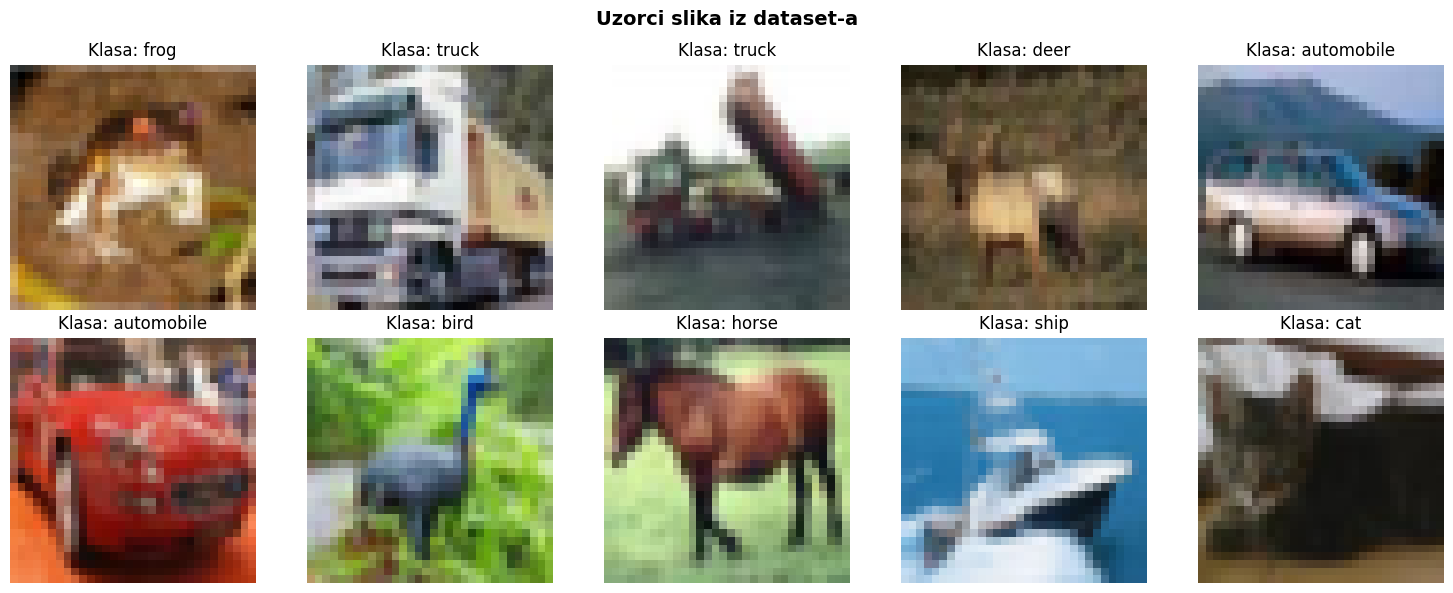

In [7]:
#Prikaz nekoliko slika
fig, axes = plt.subplots(2, 5, figsize=(15,6))
fig.suptitle('Uzorci slika iz dataset-a', fontsize=14, fontweight='bold')

for i, ax in enumerate(axes.flat):
    ax.imshow(X[i])
    ax.set_title(f"Klasa: {trainer.classes[y[i]]}")
    ax.axis('off')

plt.tight_layout()
plt.savefig("training_result/image_samples.png", dpi=300, bbox_inches="tight")
plt.show()

### Definisanje hiperparametara

In [8]:
#Baseline konfiguracija
baseline_config = {
    'num_conv_blocks': 3,
    'filter': [32, 64, 128],
    'kernel_size': 3,
    'dense_units': 256,
    'dropout_rate': 0.5,
    'learning_rate': 0.001
}

print("Baseline hiperparametri")
for key, value in baseline_config.items():
    print(f"  {key}: {value}")

Baseline hiperparametri
  num_conv_blocks: 3
  filter: [32, 64, 128]
  kernel_size: 3
  dense_units: 256
  dropout_rate: 0.5
  learning_rate: 0.001


### Treniranje sa Cross-Validacijom

In [9]:
#Treniranje sa 5-fold cross-validacijom
results = trainer.train_with_cross_validation(
    X, y,
    config=baseline_config,
    n_folds=5,
    epochs=30,
    batch_size=64
)

print("\nTreniranje zavrseno!")


Cross-validation sa 5 fold-ova

Fold 1/5
------------------------------------------------------------
  Train: 4000 uzoraka
  Val:   1000 uzoraka
  Val Loss: 1.1043
  Val Acc:  0.6790

Fold 2/5
------------------------------------------------------------
  Train: 4000 uzoraka
  Val:   1000 uzoraka
  Val Loss: 1.1820
  Val Acc:  0.6520

Fold 3/5
------------------------------------------------------------
  Train: 4000 uzoraka
  Val:   1000 uzoraka
  Val Loss: 1.1040
  Val Acc:  0.6440

Fold 4/5
------------------------------------------------------------
  Train: 4000 uzoraka
  Val:   1000 uzoraka
  Val Loss: 1.2243
  Val Acc:  0.6070

Fold 5/5
------------------------------------------------------------
  Train: 4000 uzoraka
  Val:   1000 uzoraka
  Val Loss: 1.2297
  Val Acc:  0.6160

REZULTATI CROSS-VALIDACIJE
  Prosečna Val Loss:     1.1689
  Prosečna Val Accuracy: 0.6396 ± 0.0259

Treniranje zavrseno!


### Analiza rezultata


Rezultati po fold-u:


,fold,val_loss,val_accuracy,train_loss,train_accuracy,epochs_trained
0,1,1.104262,0.679,0.120638,0.96375,30
1,2,1.182004,0.652,0.246349,0.91700,30
2,3,1.104019,0.644,0.163826,0.95400,27
3,4,1.224283,0.607,0.161647,0.95125,25
4,5,1.229703,0.616,0.112821,0.97025,30


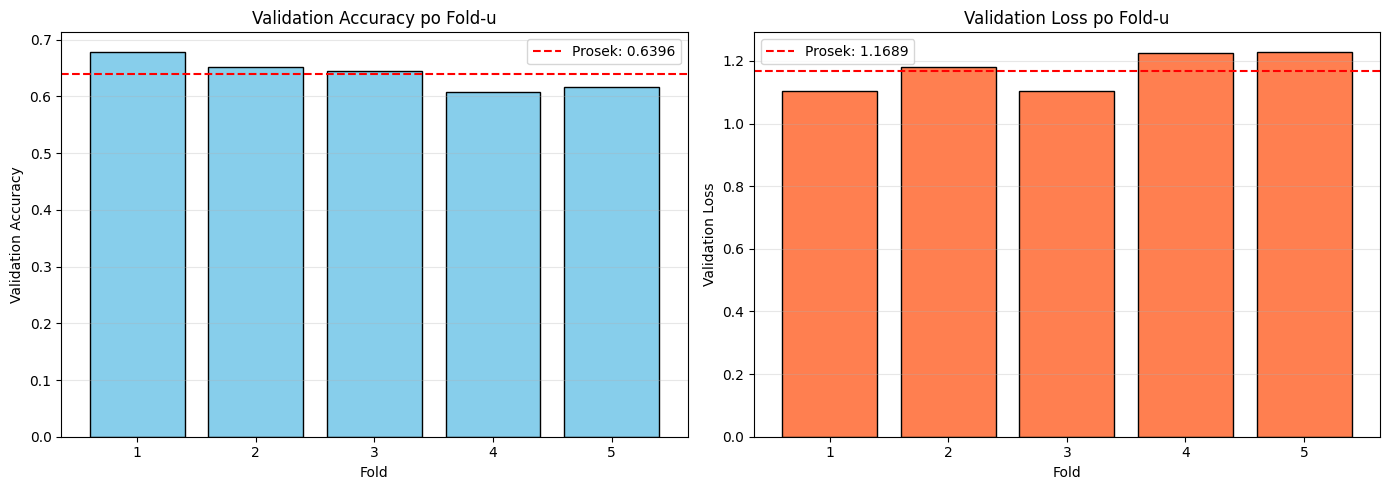

In [10]:
#Prikaz rezultata po fold-u
fold_df = pd.DataFrame(results['fold_results'])
print("\nRezultati po fold-u:")
display(fold_df)

#Vizualizacija
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

#Val Accuracy po fold-u
axes[0].bar(fold_df['fold'], fold_df['val_accuracy'], color='skyblue', edgecolor='black')
axes[0].axhline(y=results['avg_val_accuracy'], color='red', linestyle='--', 
                label=f"Prosek: {results['avg_val_accuracy']:.4f}")
axes[0].set_xlabel('Fold')
axes[0].set_ylabel('Validation Accuracy')
axes[0].set_title('Validation Accuracy po Fold-u')
axes[0].legend()
axes[0].grid(axis='y', alpha=0.3)

#Val Loss po fold-u
axes[1].bar(fold_df['fold'], fold_df['val_loss'], color='coral', edgecolor='black')
axes[1].axhline(y=results['avg_val_loss'], color='red', linestyle='--',
                label=f"Prosek: {results['avg_val_loss']:.4f}")
axes[1].set_xlabel('Fold')
axes[1].set_ylabel('Validation Loss')
axes[1].set_title('Validation Loss po Fold-u')
axes[1].legend()
axes[1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig("training_result/result_by_fold.png", dpi=300, bbox_inches="tight")
plt.show()